# Neural Network(MLP,CNN) Implementation using Keras

* This notebook is the extension of [Neural Net from Scratch](https://colab.research.google.com/drive/1Dn1QJ2sIGOEZ4O6Fy5xAtZsRngtgmn9e)
 * This notebook will implement Neural Net(**MLP,CNN**) using tensorflow keras framework

## Packages

In [1]:
import keras
import random
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import Model
from keras.applications import MobileNetV2
from keras import layers,datasets,optimizers,regularizers,models
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity

In [2]:
physical_devices = tf.config.list_physical_devices()

if physical_devices:
    print("Available physical devices:")
    for device in physical_devices:
        print(f"- {device.name} ({device.device_type})")
else:
    print("No physical devices available (TensorFlow not initialized or no devices found).")

Available physical devices:
- /physical_device:CPU:0 (CPU)
- /physical_device:GPU:0 (GPU)


## Helper function

### ProgressBar CallBack

In [ ]:
class CustomProgbarLogger(keras.callbacks.Callback):
    def __init__(self, print_every=100):
        super().__init__()
        self.print_every = print_every

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            return  # safety check

        total_epochs = self.params['epochs']
        epoch_display = epoch + 1  # convert 0-based -> 1-based

        # Print on 1st epoch, every `print_every`, and the final epoch
        if (epoch_display == 1 or
            epoch_display % self.print_every == 0 or
            epoch_display == total_epochs):

            print(
                f"Epoch {epoch_display}/{total_epochs} - "
                f"loss: {logs.get('loss', float('nan')):.4f} - "
                f"accuracy: {logs.get('accuracy', float('nan')):.4f} | "
                f"val_loss: {logs.get('val_loss', float('nan')):.4f} - "
                f"val_accuracy: {logs.get('val_accuracy', float('nan')):.4f}"
            )

### Early Stop Callback

In [ ]:
EarlyStopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=500,
    restore_best_weights=True
)

### Reduce Learning Rate

In [ ]:
ReduceLR = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=500,
    min_lr=1e-6,
    verbose=1
)

### DataAugmentor

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,              # randomly rotate images by up to 10 degrees
    width_shift_range=0.1,          # randomly shift images horizontally by 10% of width
    height_shift_range=0.1,         # randomly shift images vertically by 10% of height
    horizontal_flip=True,           # randomly flip images horizontally
    zoom_range=0.1,                 # random zoom
    brightness_range=[0.8, 1.2],    # random brightness adjustment
    channel_shift_range=20.0,       # random RGB channel shifts
    shear_range=0.1,                # shear transformation
    fill_mode='nearest',
    rescale=1./255
)

## Data Loading and Preprocessing

### Load Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print(f"Original CIFAR-10 train shapes: x={x_train.shape}, y={y_train.shape}")
print(f"Original CIFAR-10 test shapes: x={x_test.shape}, y={y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Original CIFAR-10 train shapes: x=(50000, 32, 32, 3), y=(50000, 1)
Original CIFAR-10 test shapes: x=(10000, 32, 32, 3), y=(10000, 1)


### Data preprocssing

In [4]:
# For example, let's choose 'cat' (label 3) and 'dog' (label 5)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
class_1_label = 3 # cat
class_2_label = 5 # dog

# Select images and labels belonging to the chosen classes
train_filter = np.where((y_train == class_1_label) | (y_train == class_2_label))[0]
test_filter = np.where((y_test == class_1_label) | (y_test == class_2_label))[0]

x_train, y_train = x_train[train_filter], y_train[train_filter]
x_test, y_test = x_test[test_filter], y_test[test_filter]

# Convert labels to binary (0 for class_1, 1 for class_2)
y_train = np.where(y_train == class_1_label, 0, 1)
y_test = np.where(y_test == class_1_label, 0, 1)

# Normalize the pixel values to be between 0 and 1
# x_train = x_train / 255.0
# x_test = x_test / 255.0

# Suppose x_test and y_test are tf.Tensors
x_test_np = x_test.numpy() if tf.is_tensor(x_test) else x_test
y_test_np = y_test.numpy() if tf.is_tensor(y_test) else y_test

# Split into Test into validation (50%) and test (50%)
x_val, x_test, y_val, y_test = train_test_split(
    x_test_np, y_test_np,
    test_size=0.5,          # 50% goes to final test
    stratify=y_test_np,        # preserve class balance
    random_state=42         # reproducibility
)

# Print shapes to see the size of the binary dataset
print(f"\nBinary train shapes (cat vs dog): x={x_train.shape}, y={y_train.shape}")
print(f"Binary validation shapes (cat vs dog): x={x_val.shape}, y={y_val.shape}")
print(f"Binary test shapes (cat vs dog): x={x_test.shape}, y={y_test.shape}")


Binary train shapes (cat vs dog): x=(10000, 32, 32, 3), y=(10000, 1)
Binary validation shapes (cat vs dog): x=(1000, 32, 32, 3), y=(1000, 1)
Binary test shapes (cat vs dog): x=(1000, 32, 32, 3), y=(1000, 1)


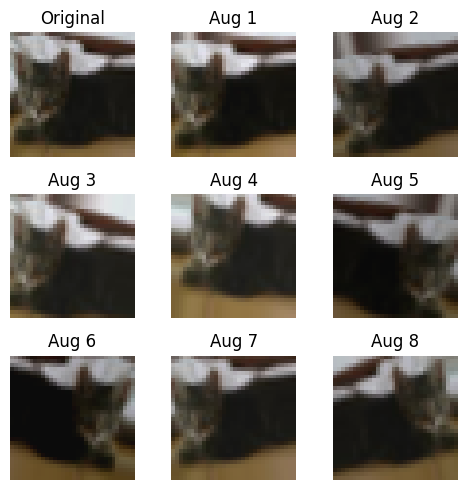

In [ ]:
# Pick one sample image from training data
img = x_train[0]  # You can change the index to view another image
img_array = img.reshape((1,) + img.shape)

# Plot original image
plt.figure(figsize=(5, 5))
plt.subplot(3, 3, 1)
plt.imshow(img.astype("uint8"))
plt.title("Original")
plt.axis("off")

# Generate and plot augmentations
i = 0
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(3, 3, i + 2)
    plt.imshow(tf.cast(batch[0] / 255.0, tf.float32))
    plt.title(f"Aug {i+1}")
    plt.axis("off")
    i += 1
    if i == 8:  # show 8 augmentations
        break

plt.tight_layout()
plt.show()

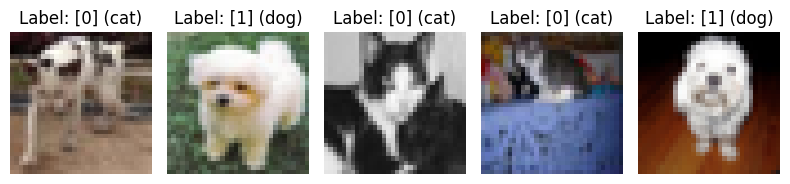

In [ ]:
# Optional: Display a few images from the binary dataset
plt.figure(figsize=(8,8))
for k in range(5):
    plt.subplot(1, 5, k + 1)
    i = random.randrange(len(x_train))
    plt.imshow(x_train[i])
    plt.title(f"Label: {y_train[i]} ({class_names[class_1_label] if y_train[i] == 0 else class_names[class_2_label]})")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Model Training and Testing

### Basic MLP Model

#### Network Architecture

In [ ]:
def mlp_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),  # Input layer
        layers.Flatten(),  # Flatten the 32x32 pixel images
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='tanh'),
        layers.Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    return model

In [ ]:
mlp_model = mlp_classifier()
optimizer = optimizers.SGD(learning_rate=0.1)
mlp_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,297 (778.50 KB)

 Trainable params: 199,297 (778.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Training

In [ ]:
epochs, batch_size = 20000, len(x_train)
total_print = 25
mlp_model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, callbacks=[CustomProgbarLogger(print_every=epochs // total_print)], verbose=0)

#### Model Evaluation

In [ ]:
mlp_model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


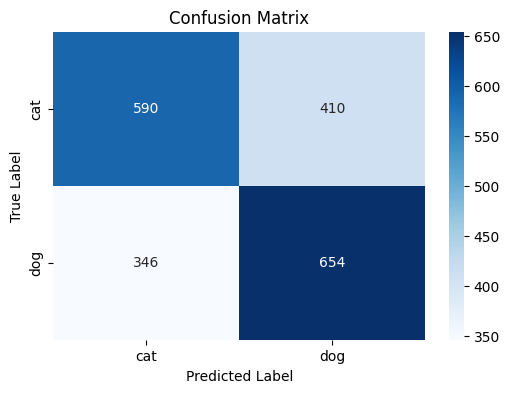

In [ ]:
y_pred = mlp_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### MLP with Batch Normalization

#### Network Architecture

In [ ]:
def mlp_bn_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),  # Input layer
        layers.Flatten(),  # Flatten the 32x32 pixel images
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),\
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    return model

#### Model Training

In [ ]:
mlp_bn_model = mlp_bn_classifier()
optimizer = optimizers.SGD(learning_rate=0.1)
mlp_bn_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
mlp_bn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,681 (780.00 KB)

 Trainable params: 199,489 (779.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
epochs, batch_size = 20000, len(x_train)
total_print = 25
mlp_bn_model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, callbacks=[CustomProgbarLogger(print_every=epochs // total_print)], verbose=0)

Epoch 1/20000 - loss: 0.8105 - accuracy: 0.4955
Epoch 800/20000 - loss: 0.5041 - accuracy: 0.7404
Epoch 1600/20000 - loss: 0.3547 - accuracy: 0.8350
Epoch 2400/20000 - loss: 0.2471 - accuracy: 0.8964
Epoch 3200/20000 - loss: 0.2335 - accuracy: 0.9000
Epoch 4000/20000 - loss: 0.1668 - accuracy: 0.9345
Epoch 4800/20000 - loss: 0.1452 - accuracy: 0.9454
Epoch 5600/20000 - loss: 0.1365 - accuracy: 0.9485
Epoch 6400/20000 - loss: 0.1020 - accuracy: 0.9613
Epoch 7200/20000 - loss: 0.0857 - accuracy: 0.9704
Epoch 8000/20000 - loss: 0.1669 - accuracy: 0.9362
Epoch 8800/20000 - loss: 0.0981 - accuracy: 0.9631
Epoch 9600/20000 - loss: 0.1006 - accuracy: 0.9635
Epoch 10400/20000 - loss: 0.0851 - accuracy: 0.9672
Epoch 11200/20000 - loss: 0.0744 - accuracy: 0.9751
Epoch 12000/20000 - loss: 0.0483 - accuracy: 0.9835
Epoch 12800/20000 - loss: 0.0746 - accuracy: 0.9746
Epoch 13600/20000 - loss: 0.0802 - accuracy: 0.9726
Epoch 14400/20000 - loss: 0.0526 - accuracy: 0.9810
Epoch 15200/20000 - loss: 0.0

#### Model Evaluation

In [ ]:
mlp_bn_model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6280 - loss: 2.3344


[2.416027784347534, 0.6190000176429749]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


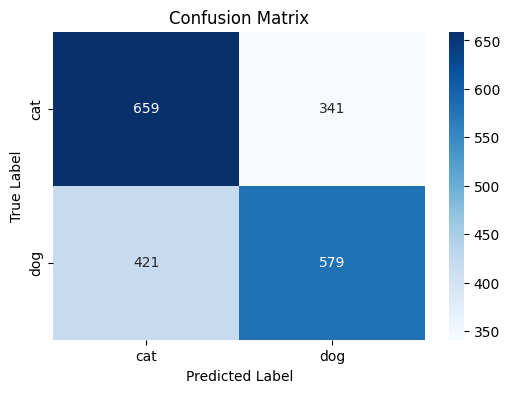

In [ ]:
y_pred = mlp_bn_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Basic CNN Model

#### Network Architecture

In [ ]:
def cnn_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),  # Input layer
        layers.ZeroPadding2D(padding=(2, 2)),
        layers.Conv2D(filters=32, kernel_size=(7,7), strides=(1,1), name='conv0'),
        layers.BatchNormalization(axis=3, name='bn0'),
        layers.ReLU(name='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    return model

#### Model Training

In [ ]:
cnn_model = cnn_classifier()
#optimizer = optimizers.SGD(learning_rate=0.1)
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d_3                │ (None, 36, 36, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 30, 30, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 30, 30, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu (ReLU)                     │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         7,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,065 (47.13 KB)

 Trainable params: 12,001 (46.88 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
epochs, batch_size = 5000, len(x_train)
total_print = 25
history = cnn_model.fit(x_train, y_train,
              epochs=epochs,
              batch_size=batch_size,
              validation_data=(x_val, y_val),
              callbacks=[CustomProgbarLogger(print_every=epochs//total_print),EarlyStopping],
              verbose=0)

Epoch 1/5000 - loss: 0.6615 - accuracy: 0.6173 | val_loss: 0.6892 - val_accuracy: 0.5330
Epoch 200/5000 - loss: 0.4763 - accuracy: 0.7768 | val_loss: 0.6433 - val_accuracy: 0.5930
Epoch 400/5000 - loss: 0.3905 - accuracy: 0.8283 | val_loss: 0.5797 - val_accuracy: 0.6800
Epoch 600/5000 - loss: 0.3249 - accuracy: 0.8694 | val_loss: 0.6508 - val_accuracy: 0.6660
Epoch 800/5000 - loss: 0.2638 - accuracy: 0.9087 | val_loss: 0.5969 - val_accuracy: 0.7240
Epoch 1000/5000 - loss: 0.2211 - accuracy: 0.9319 | val_loss: 0.7695 - val_accuracy: 0.6840


#### Model Evaluation

In [ ]:
cnn_model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7350 - loss: 0.5475


[0.5483859181404114, 0.7310000061988831]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

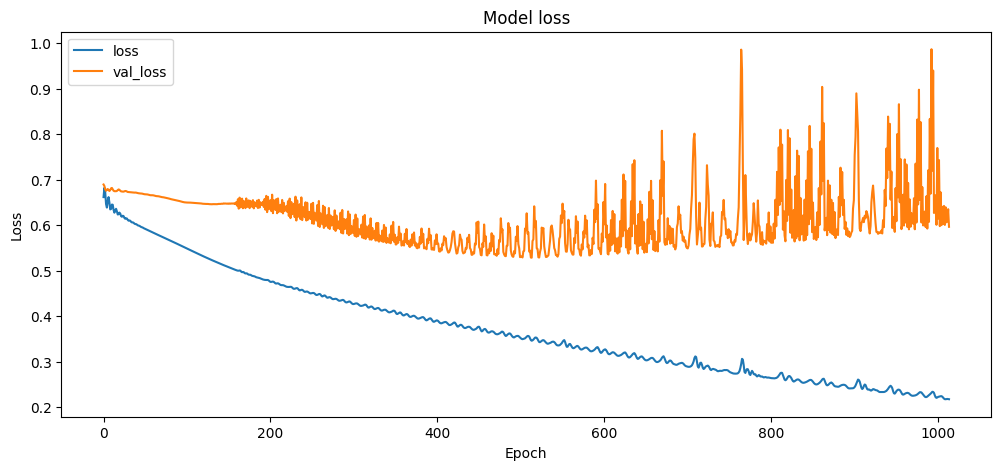

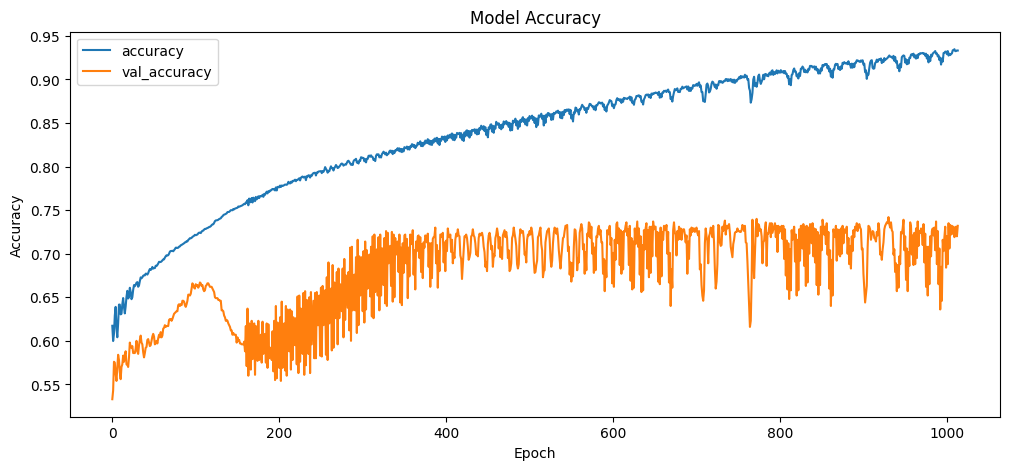

In [ ]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


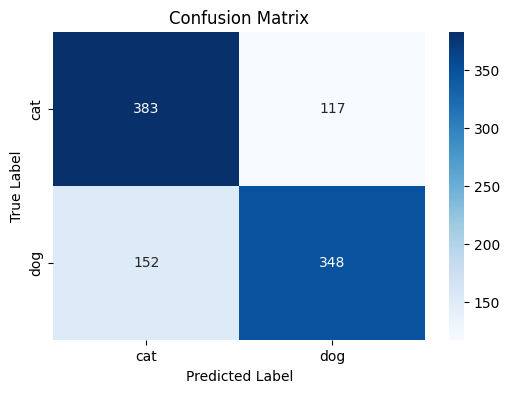

In [ ]:
y_pred = cnn_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### CNN With BN and Dropout

#### Network Architecture

In [ ]:
def cnn_lenet5_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),  # Input layer
        layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), use_bias=False, name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2, name='pool1'),
        layers.Dropout(0.25),

        layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), use_bias=False, name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2, name='pool2'),
        layers.Dropout(0.25),

        layers.Flatten(name='flat1'),

        layers.Dense(64, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.Dropout(0.5),

        layers.Dense(16, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid', name='output') # Output layer for binary classification
    ])
    return model

#### Model Training

In [ ]:
cnn_lenet5_model = cnn_lenet5_classifier()
#optimizer = optimizers.SGD(learning_rate=0.1)
cnn_lenet5_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_lenet5_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 28, 28, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10, 10, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flat1 (Flatten)                 │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,899 (116.79 KB)

 Trainable params: 29,695 (116.00 KB)

 Non-trainable params: 204 (816.00 B)

In [ ]:
epochs, batch_size = 2000, len(x_train)
total_print = 25
history = cnn_lenet5_model.fit(x_train, y_train,
                               epochs=epochs,
                               batch_size=batch_size,
                               validation_data=(x_val, y_val),
                               callbacks=[CustomProgbarLogger(print_every=epochs//total_print),
                                          EarlyStopping,
                                          ReduceLR],
                               verbose=0)

Epoch 1/2000 - loss: 0.8363 - accuracy: 0.5010 | val_loss: 0.6998 - val_accuracy: 0.5000
Epoch 80/2000 - loss: 0.6596 - accuracy: 0.6275 | val_loss: 0.8874 - val_accuracy: 0.5080
Epoch 160/2000 - loss: 0.6172 - accuracy: 0.6769 | val_loss: 0.6499 - val_accuracy: 0.6200
Epoch 240/2000 - loss: 0.5839 - accuracy: 0.7011 | val_loss: 0.6335 - val_accuracy: 0.6410
Epoch 320/2000 - loss: 0.5595 - accuracy: 0.7210 | val_loss: 0.5928 - val_accuracy: 0.6800
Epoch 400/2000 - loss: 0.5408 - accuracy: 0.7308 | val_loss: 0.5828 - val_accuracy: 0.6860
Epoch 480/2000 - loss: 0.5268 - accuracy: 0.7447 | val_loss: 0.6021 - val_accuracy: 0.6850
Epoch 560/2000 - loss: 0.5178 - accuracy: 0.7479 | val_loss: 0.6420 - val_accuracy: 0.6660
Epoch 640/2000 - loss: 0.5055 - accuracy: 0.7608 | val_loss: 0.5773 - val_accuracy: 0.7120
Epoch 720/2000 - loss: 0.5010 - accuracy: 0.7617 | val_loss: 0.6365 - val_accuracy: 0.6730
Epoch 800/2000 - loss: 0.5020 - accuracy: 0.7628 | val_loss: 0.5773 - val_accuracy: 0.7140
Ep

#### Model Evaluation

In [ ]:
cnn_lenet5_model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7631 - loss: 0.4946


[0.5084996223449707, 0.7590000033378601]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

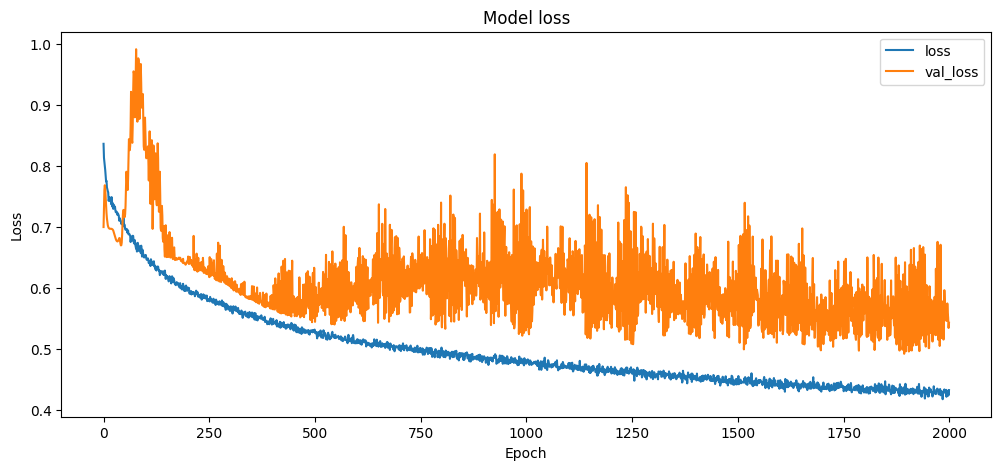

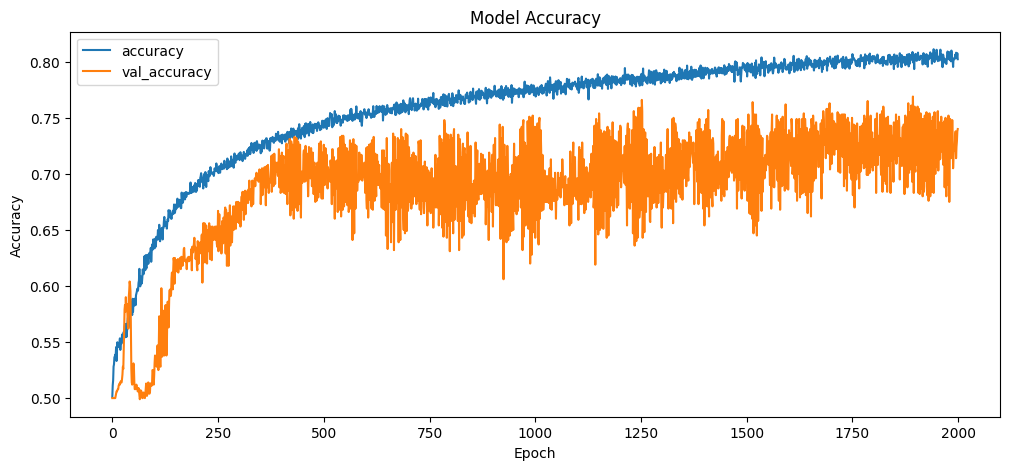

In [ ]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


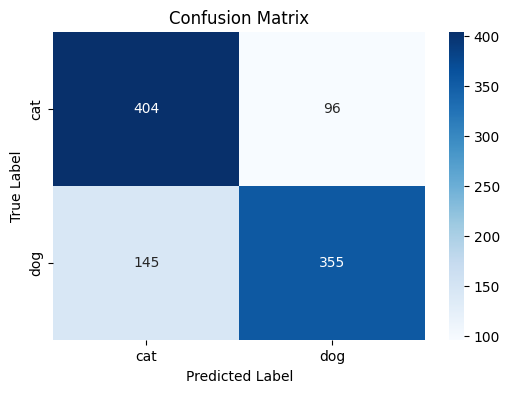

In [ ]:
y_pred = cnn_lenet5_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### CNN with Data Augmentation

#### Network Architecture

In [ ]:
def cnn_with_data_aug_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),  # Input layer
        layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), use_bias=False, name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2, name='pool1'),
        # layers.Dropout(0.25),

        layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), use_bias=False, name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2, name='pool2'),
        # layers.Dropout(0.25),

        layers.Flatten(name='flat1'),

        layers.Dense(64, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        # layers.Dropout(0.5),

        layers.Dense(16, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('tanh'),
        # layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid', name='output') # Output layer for binary classification
    ])
    return model

#### Model Training

In [ ]:
cnn_with_data_aug_model = cnn_with_data_aug_classifier()
#optimizer = optimizers.SGD(learning_rate=0.1)
cnn_with_data_aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_with_data_aug_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flat1 (Flatten)                 │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,899 (116.79 KB)

 Trainable params: 29,695 (116.00 KB)

 Non-trainable params: 204 (816.00 B)

In [ ]:
epochs, batch_size = 1000, len(x_train)
total_print = 25
history = cnn_with_data_aug_model.fit(
                               datagen.flow(x_train, y_train, batch_size=batch_size),
                               epochs=epochs,
                              #  batch_size=batch_size,
                               validation_data=(x_val, y_val),
                               callbacks=[CustomProgbarLogger(print_every=epochs//total_print),
                                          EarlyStopping,
                                          ReduceLR],
                               verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000 - loss: 0.4217 - accuracy: 0.8062 | val_loss: 0.5369 - val_accuracy: 0.7330
Epoch 40/1000 - loss: 0.4127 - accuracy: 0.8100 | val_loss: 0.5842 - val_accuracy: 0.7050
Epoch 80/1000 - loss: 0.4151 - accuracy: 0.8051 | val_loss: 0.5524 - val_accuracy: 0.7330
Epoch 120/1000 - loss: 0.4021 - accuracy: 0.8207 | val_loss: 0.5768 - val_accuracy: 0.7170
Epoch 160/1000 - loss: 0.4057 - accuracy: 0.8164 | val_loss: 0.6034 - val_accuracy: 0.7110
Epoch 200/1000 - loss: 0.4025 - accuracy: 0.8129 | val_loss: 0.5816 - val_accuracy: 0.7180
Epoch 240/1000 - loss: 0.3934 - accuracy: 0.8164 | val_loss: 0.5823 - val_accuracy: 0.7150
Epoch 280/1000 - loss: 0.3950 - accuracy: 0.8237 | val_loss: 0.6379 - val_accuracy: 0.6930
Epoch 320/1000 - loss: 0.4010 - accuracy: 0.8175 | val_loss: 0.5504 - val_accuracy: 0.7480
Epoch 360/1000 - loss: 0.3952 - accuracy: 0.8210 | val_loss: 0.5938 - val_accuracy: 0.7140
Epoch 400/1000 - loss: 0.3938 - accuracy: 0.8210 | val_loss: 0.5692 - val_accuracy: 0.7290
Epo

#### Model Evaluation

In [ ]:
cnn_with_data_aug_model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7773 - loss: 0.4643


[0.48772308230400085, 0.7630000114440918]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

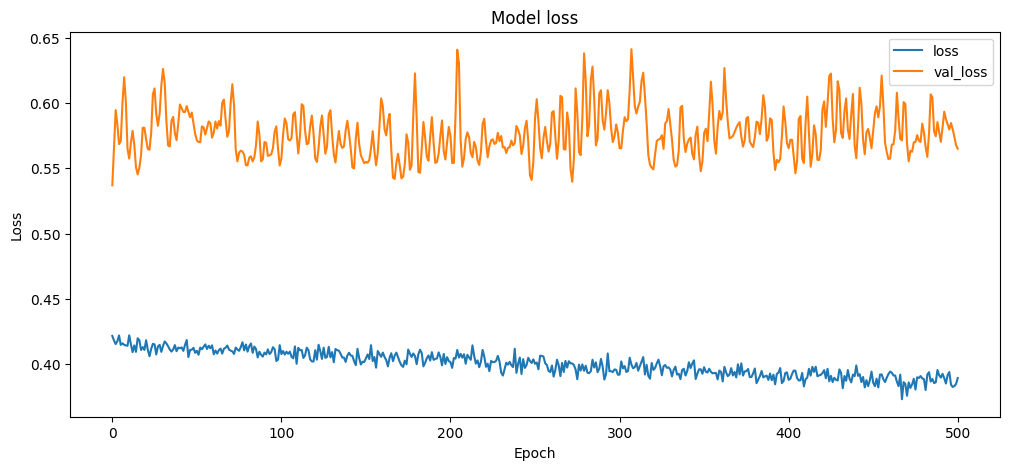

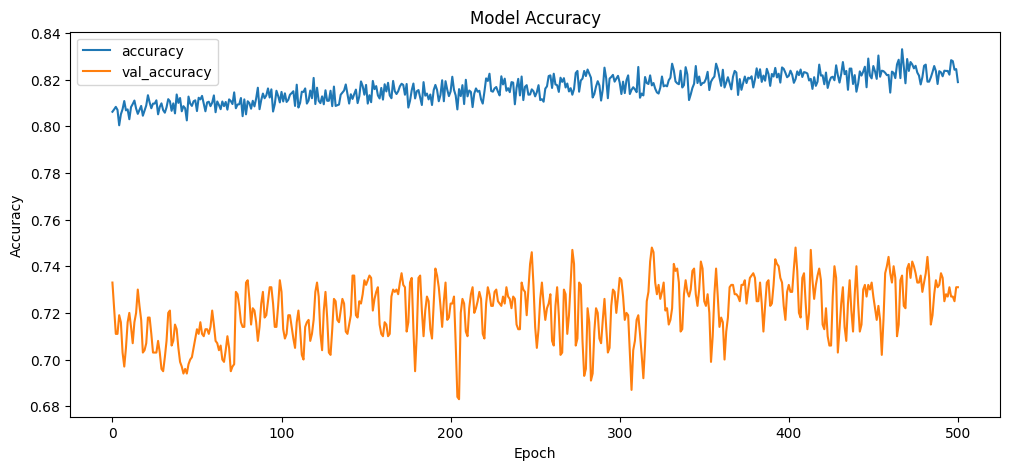

In [ ]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


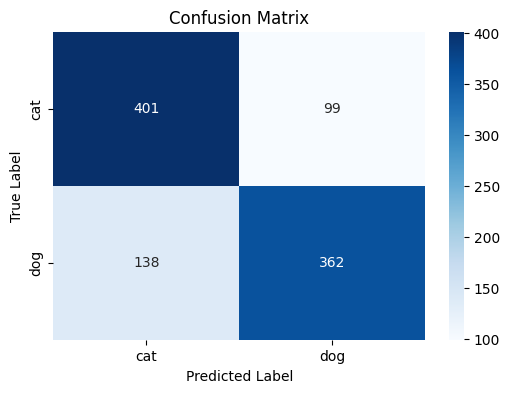

In [ ]:
y_pred = cnn_with_data_aug_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Larger CNN with Data Augmentation

#### Network Architecture
  

In [ ]:
def large_cnn_with_data_aug_classifier():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv2D(32, (3,3), padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2), strides=2),
        # layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Conv2D(64, (3,3), padding='same', name='conv4'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2), strides=2),
        # layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same', name='conv5'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2), strides=2),
        # layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        # layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

#### Model Training

In [ ]:
large_cnn_with_data_aug_model = large_cnn_with_data_aug_classifier()
#optimizer = optimizers.SGD(learning_rate=0.1)
large_cnn_with_data_aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
large_cnn_with_data_aug_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 128)            │             

 Total params: 403,617 (1.54 MB)

 Trainable params: 402,721 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
epochs, batch_size = 1000, len(x_train)
total_print = 25
history = large_cnn_with_data_aug_model.fit(
                               datagen.flow(x_train, y_train, batch_size=batch_size),
                               epochs=epochs,
                              #  batch_size=batch_size,
                               validation_data=(x_val, y_val),
                               callbacks=[CustomProgbarLogger(print_every=epochs//total_print),
                                          EarlyStopping,
                                          ReduceLR],
                               verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000 - loss: 0.7841 - accuracy: 0.5011 | val_loss: 0.6916 - val_accuracy: 0.5640
Epoch 40/1000 - loss: 0.4449 - accuracy: 0.7854 | val_loss: 0.7346 - val_accuracy: 0.5000
Epoch 80/1000 - loss: 0.3235 - accuracy: 0.8570 | val_loss: 0.7205 - val_accuracy: 0.5000
Epoch 120/1000 - loss: 0.2465 - accuracy: 0.8998 | val_loss: 0.6982 - val_accuracy: 0.5180
Epoch 160/1000 - loss: 0.1876 - accuracy: 0.9272 | val_loss: 0.7578 - val_accuracy: 0.4950
Epoch 200/1000 - loss: 0.1482 - accuracy: 0.9451 | val_loss: 0.8755 - val_accuracy: 0.5050
Epoch 240/1000 - loss: 0.1227 - accuracy: 0.9556 | val_loss: 1.4375 - val_accuracy: 0.5060
Epoch 280/1000 - loss: 0.0969 - accuracy: 0.9670 | val_loss: 1.2378 - val_accuracy: 0.5260
Epoch 320/1000 - loss: 0.0871 - accuracy: 0.9701 | val_loss: 1.5478 - val_accuracy: 0.5500
Epoch 360/1000 - loss: 0.0680 - accuracy: 0.9763 | val_loss: 1.0403 - val_accuracy: 0.6480
Epoch 400/1000 - loss: 0.0541 - accuracy: 0.9833 | val_loss: 0.9215 - val_accuracy: 0.6970
Epo

#### Model Evaluation

In [ ]:
large_cnn_with_data_aug_model.save('large_cnn_with_data_aug_model_weight.keras')
large_cnn_with_data_aug_model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8363 - loss: 0.6121


[0.6522997617721558, 0.8299999833106995]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

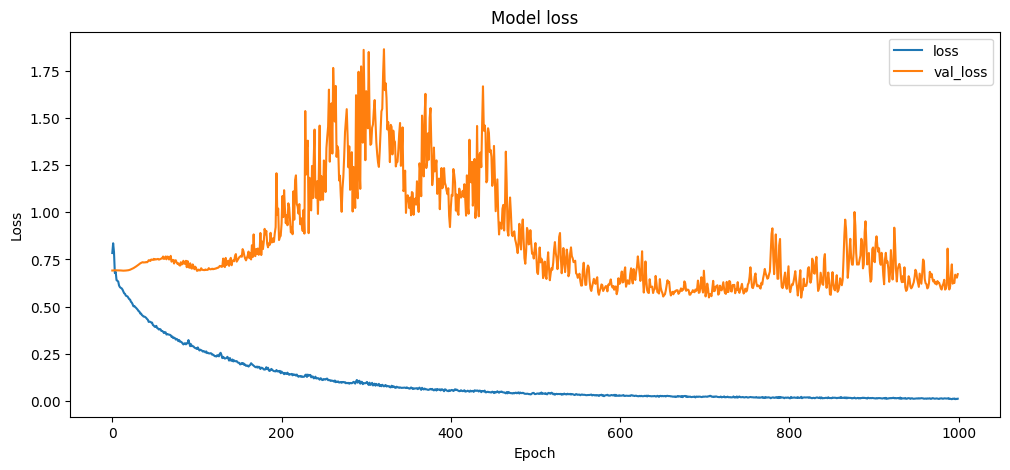

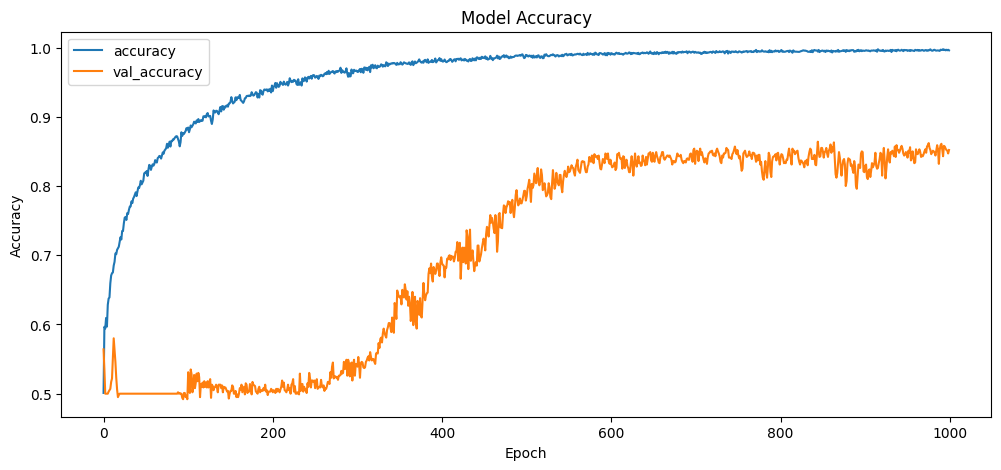

In [ ]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


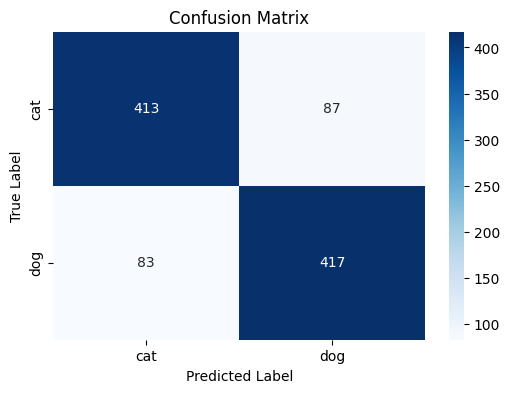

In [ ]:
y_pred = large_cnn_with_data_aug_model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Wrong prediction Analysis

In [ ]:
y_pred_prob = large_cnn_with_data_aug_model.predict(x_test)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Find wrong predictions
wrong_idx = np.where(y_pred_class != y_test)[0]

# Get predicted probabilities for wrong predictions
wrong_pred_probs = y_pred_prob[wrong_idx]

print("Count of wrong predictions:", len(wrong_pred_probs))

print(f"min, mean and max, {np.min(wrong_pred_probs), np.mean(wrong_pred_probs), np.max(wrong_pred_probs)}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Count of wrong predictions: 170
min, mean and max, (np.float32(3.500362e-05), np.float32(0.5178014), np.float32(0.9999987))


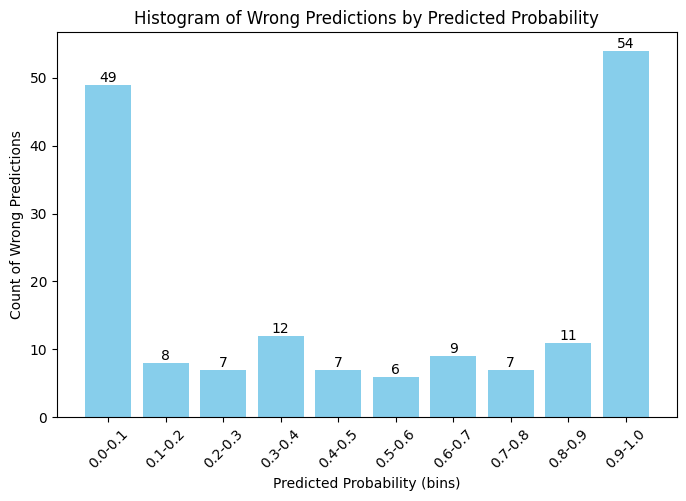

In [ ]:
# Define bins: 0-0.1, 0.1-0.2, ..., 0.9-1
bins = np.arange(0, 1.1, 0.1)  # 0.0, 0.1, ..., 1.0

# Compute histogram
counts, edges = np.histogram(wrong_pred_probs, bins=bins)

# Plot bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(range(len(counts)), counts, tick_label=[f"{edges[i]:.1f}-{edges[i+1]:.1f}" for i in range(len(counts))], color='skyblue')

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count), ha='center', va='bottom')

plt.xlabel("Predicted Probability (bins)")
plt.ylabel("Count of Wrong Predictions")
plt.title("Histogram of Wrong Predictions by Predicted Probability")
plt.xticks(rotation=45)
plt.show()


Number of misclassified images: 170


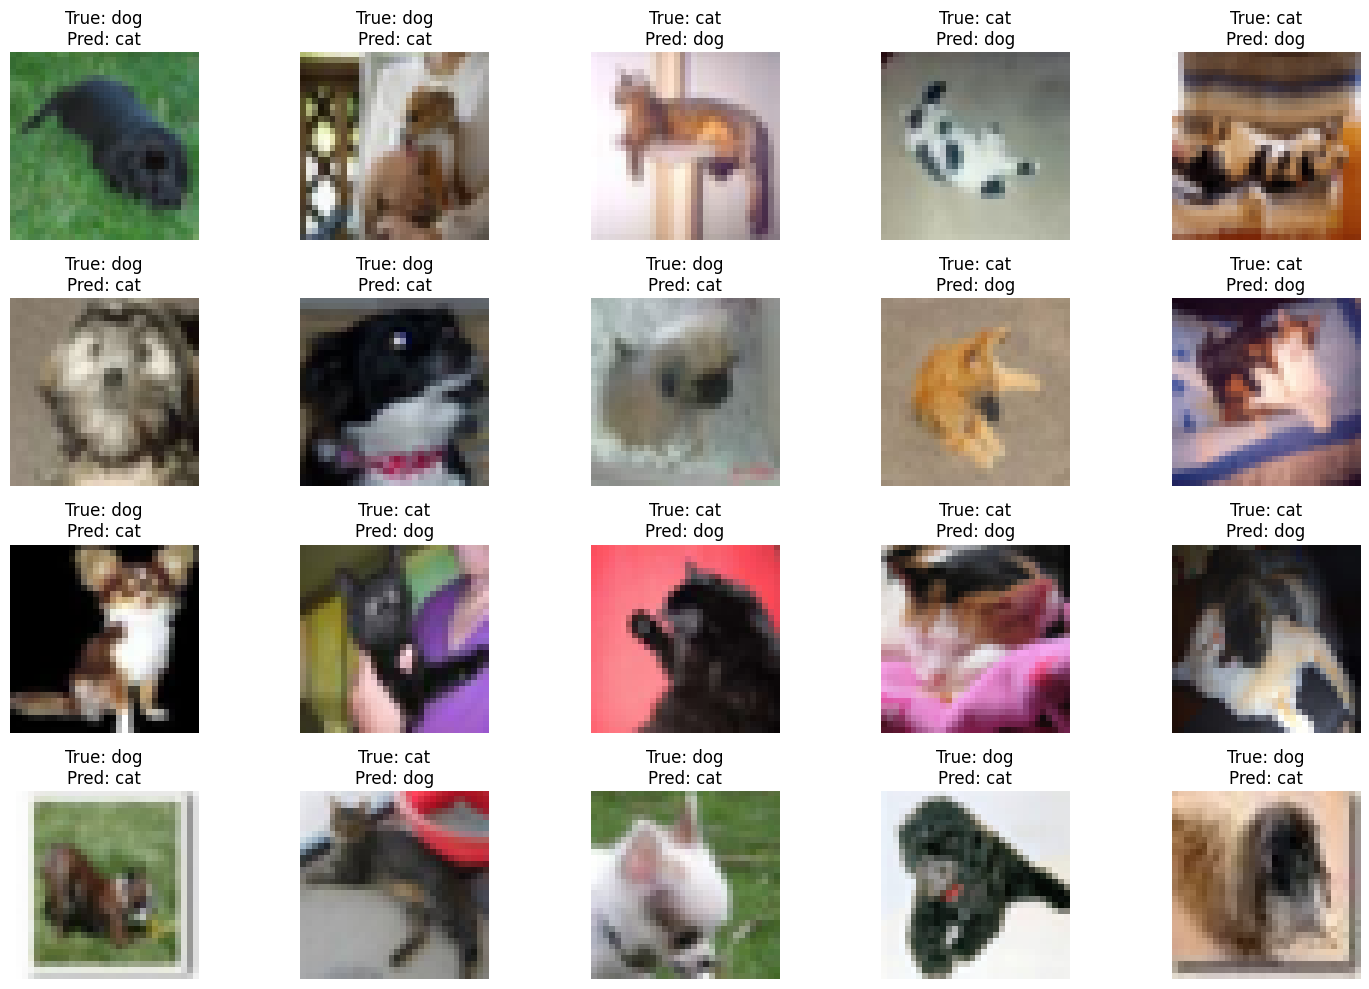

In [ ]:

# Find the indices where the true labels do not match the predicted labels
misclassified_indices = np.where(y_pred_class != y_test)[0]

# Print the number of misclassified images
print(f"Number of misclassified images: {len(misclassified_indices)}")

# Filter for high-confidence errors: probability <0.1 or >0.9
misclassified_indices = [i for i in misclassified_indices if y_pred_prob[i] < 0.05 or y_pred_prob[i] > 0.95]


# Plot a few of the misclassified images
plt.figure(figsize=(15, 10))


num_images_to_plot = min(20, len(misclassified_indices)) # Plot up to 20 misclassified images

for i in range(num_images_to_plot):
    index = misclassified_indices[i]
    plt.subplot(4, 5, i + 1) # Adjust subplot grid based on the number of images
    # Display the original image from the test set
    plt.imshow(x_test[index])
    # Display the true and predicted labels
    true_label = class_names[class_1_label] if y_test[index] == 0 else class_names[class_2_label]
    predicted_label = class_names[class_1_label] if y_pred_class[index] == 0 else class_names[class_2_label]
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Transfer Learning With EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


# -----------------------------
# 1. Parameters
# -----------------------------
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS_PHASE1 = 30  # training classifier head
EPOCHS_PHASE2 = 20  # fine-tuning top layers
DENSE_UNITS = 128

# -----------------------------
# 2. Resize images from 32x32 to 96x96
# -----------------------------
x_train_resized = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE)).numpy()
x_val_resized  = tf.image.resize(x_val, (IMG_SIZE, IMG_SIZE)).numpy()
x_test_resized  = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE)).numpy()

# -----------------------------
# 3. Data Augmentation for Training
# -----------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # normalize to [-1,1]
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # only normalization
)

# Generators
train_gen = train_datagen.flow(
    x_train_resized, y_train,
    batch_size=BATCH_SIZE, subset='training'
)

val_gen = val_datagen.flow(
    x_val_resized, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False  # keep order fixed
)

# Test generator
test_gen = val_datagen.flow(
    x_test_resized, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# -----------------------------
# 4. Load Pretrained EfficientNetB0
# -----------------------------
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # freeze base initially

# Add classification head
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(DENSE_UNITS, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary classification

model = models.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 5. Callbacks
# -----------------------------
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# -----------------------------
# 6. Phase 1: Train classifier head
# -----------------------------
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)

# -----------------------------
# 7. Phase 2: Fine-tuning top layers
# -----------------------------
base_model.trainable = True
for layer in base_model.layers[:-20]:  # freeze bottom layers, fine-tune top 20
    layer.trainable = False

# Compile with lower LR for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks
)

# -----------------------------
# 8. Evaluate on Test Data
# -----------------------------
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,180 (16.08 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


282/282 ━━━━━━━━━━━━━━━━━━━━ 79s 186ms/step - accuracy: 0.7659 - loss: 0.5154 - val_accuracy: 0.8610 - val_loss: 0.3533 - learning_rate: 0.0010
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - accuracy: 0.8306 - loss: 0.3980 - val_accuracy: 0.8590 - val_loss: 0.3399 - learning_rate: 0.0010
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - accuracy: 0.8536 - loss: 0.3579 - val_accuracy: 0.8740 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.8646 - loss: 0.3377 - val_accuracy: 0.8540 - val_loss: 0.3340 - learning_rate: 0.0010
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.8649 - loss: 0.3470 - val_accuracy: 0.8650 - val_loss: 0.3342 - learning_rate: 0.0010
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.8726 - loss: 0.3289 - val_accuracy: 0.8690 - val_loss: 0.3288 - learning_rate: 0.0010
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.8574 - loss: 0.349

#### Model Evaluation

In [ ]:
model.save('efficientnet_with_tl_weight.keras')
model.evaluate(test_gen)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8901 - loss: 0.2931


[0.3151456117630005, 0.8830000162124634]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

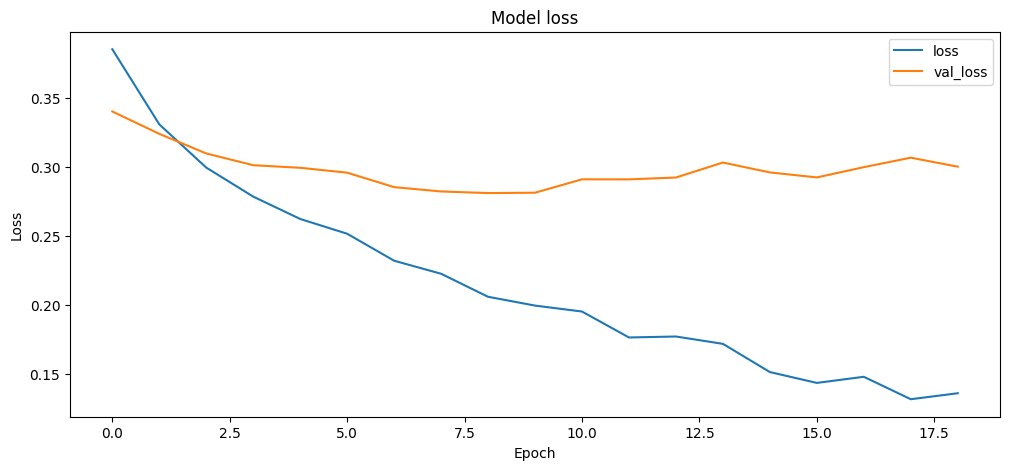

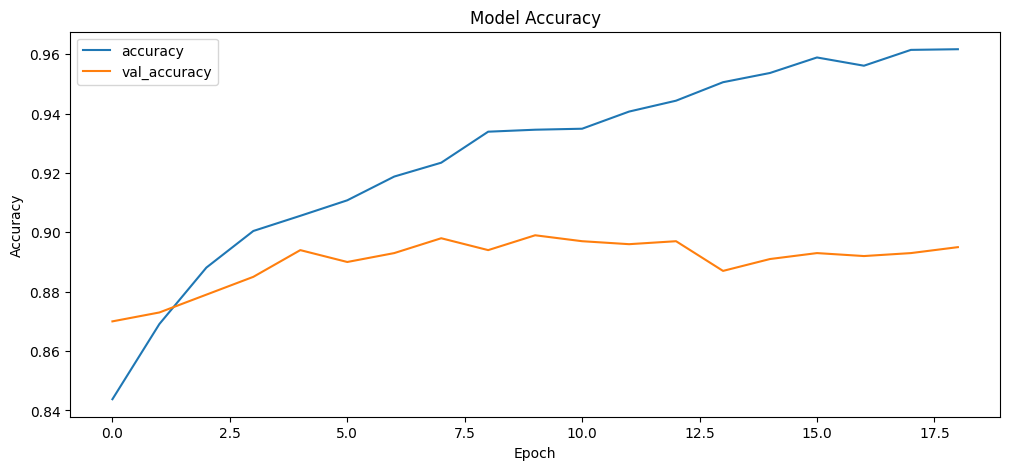

In [ ]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history_phase2.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


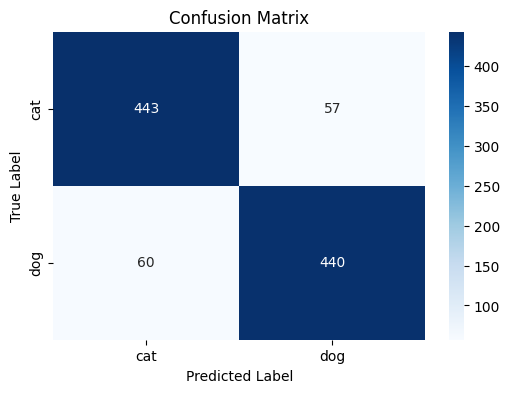

In [ ]:
y_pred = model.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Number of misclassified images: 117


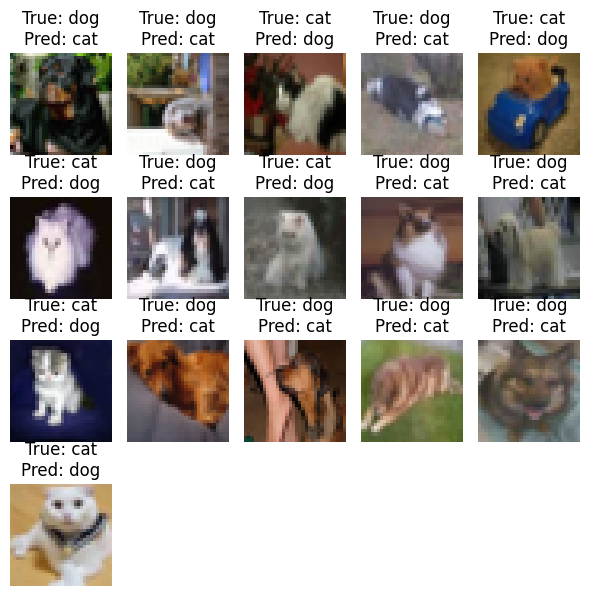

In [ ]:

# Find the indices where the true labels do not match the predicted labels
misclassified_indices = np.where(y_pred_class != y_test)[0]

# Print the number of misclassified images
print(f"Number of misclassified images: {len(misclassified_indices)}")

# Filter for high-confidence errors: probability <0.1 or >0.9
misclassified_indices = [i for i in misclassified_indices if y_pred_prob[i] < 0.05 or y_pred_prob[i] > 0.95]


# Plot a few of the misclassified images
plt.figure(figsize=(6, 6))


num_images_to_plot = min(20, len(misclassified_indices)) # Plot up to 20 misclassified images

for i in range(num_images_to_plot):
    index = misclassified_indices[i]
    plt.subplot(4, 5, i + 1) # Adjust subplot grid based on the number of images
    # Display the original image from the test set
    plt.imshow(x_test[index])
    # Display the true and predicted labels
    true_label = class_names[class_1_label] if y_test[index] == 0 else class_names[class_2_label]
    predicted_label = class_names[class_1_label] if y_pred_class[index] == 0 else class_names[class_2_label]
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Transfer learning with larger image size(from 96x96 to 128 x128)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ===============================================
# 🧠 1. Configuration
# ===============================================
IMG_SIZE = 128            # Increase from 32 -> 128 for richer detail
BATCH_SIZE = 64
EPOCHS = 75
LR_FINE_TUNE = 1e-5
WEIGHT_DECAY = 1e-5

# ===============================================
# 🧩 2. Data preprocessing and augmentation
# ===============================================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Normalize to [-1, 1]
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.1
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Resize CIFAR-10 images
x_train_resized = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_val_resized = tf.image.resize(x_val, (IMG_SIZE, IMG_SIZE))
x_test_resized = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE))

train_gen = train_datagen.flow(x_train_resized, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen = val_datagen.flow(x_val_resized, y_val, batch_size=BATCH_SIZE, shuffle=False)

# ===============================================
# 🏗️ 3. Build model — EfficientNetB0 backbone
# ===============================================
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # Phase 1 — freeze backbone

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# ===============================================
# ⚙️ 4. Phase 1 — Train classifier head
# ===============================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('efficientnetb0_phase1.h5', save_best_only=True)
]

history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ===============================================
# 🔧 5. Phase 2 — Fine-tune top layers
# ===============================================
# Unfreeze deeper portion of the model
for layer in base_model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR_FINE_TUNE, weight_decay=WEIGHT_DECAY),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint('efficientnetb0_finetuned.h5', save_best_only=True)
]

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_ft
)

# ===============================================
# 🧪 6. Evaluate
# ===============================================
test_gen = val_datagen.flow(x_test_resized, y_test, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6489 - loss: 0.6597

157/157 ━━━━━━━━━━━━━━━━━━━━ 108s 511ms/step - accuracy: 0.6494 - loss: 0.6593 - val_accuracy: 0.8480 - val_loss: 0.4588
Epoch 2/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.8051 - loss: 0.5095

157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 296ms/step - accuracy: 0.8051 - loss: 0.5095 - val_accuracy: 0.8570 - val_loss: 0.4378
Epoch 3/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8287 - loss: 0.4855

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 313ms/step - accuracy: 0.9268 - loss: 0.3451 - val_accuracy: 0.9260 - val_loss: 0.3556 - learning_rate: 1.0000e-05
Epoch 67/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9260 - loss: 0.3487

157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 315ms/step - accuracy: 0.9261 - loss: 0.3487 - val_accuracy: 0.9240 - val_loss: 0.3552 - learning_rate: 1.0000e-05
Epoch 68/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9282 - loss: 0.3438

157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 309ms/step - accuracy: 0.9282 - loss: 0.3438 - val_accuracy: 0.9250 - val_loss: 0.3551 - learning_rate: 1.0000e-05
Epoch 69/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 300ms/step - accuracy: 0.9281 - loss: 0.3463 - val_accuracy: 0.9230 - val_loss: 0.3557 - learning_rate: 1.0000e-05
Epoch 70/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 302ms/step - accuracy: 0.9296 - loss: 0.3405 - val_accuracy: 0.9270 - val_loss: 0.3552 - learning_rate: 1.0000e-05
Epoch 71/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9328 - loss: 0.3410

157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9328 - loss: 0.3410 - val_accuracy: 0.9250 - val_loss: 0.3550 - learning_rate: 1.0000e-05
Epoch 72/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 313ms/step - accuracy: 0.9357 - loss: 0.3359 - val_accuracy: 0.9280 - val_loss: 0.3552 - learning_rate: 5.0000e-06
Epoch 73/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9296 - loss: 0.3404

157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9296 - loss: 0.3404 - val_accuracy: 0.9290 - val_loss: 0.3546 - learning_rate: 5.0000e-06
Epoch 74/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.9328 - loss: 0.3374 - val_accuracy: 0.9280 - val_loss: 0.3551 - learning_rate: 5.0000e-06
Epoch 75/75
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9327 - loss: 0.3413 - val_accuracy: 0.9280 - val_loss: 0.3549 - learning_rate: 5.0000e-06
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9218 - loss: 0.3436
✅ Test accuracy: 0.9160 | Test loss: 0.3489


#### Model Evaluation

In [6]:
model.save('efficientnet_with_larger_image_tl_weight.keras')
model.evaluate(test_gen)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9218 - loss: 0.3436


[0.3489416837692261, 0.9160000085830688]

[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Accuracy')]

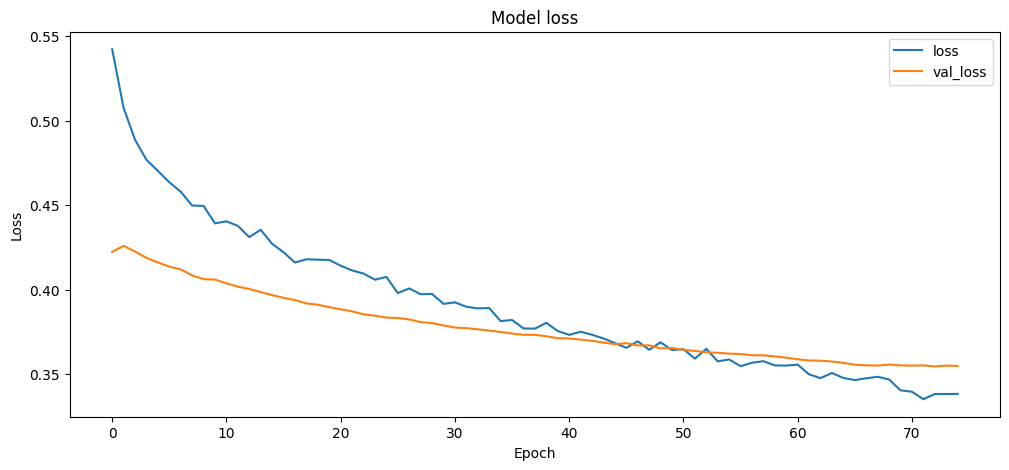

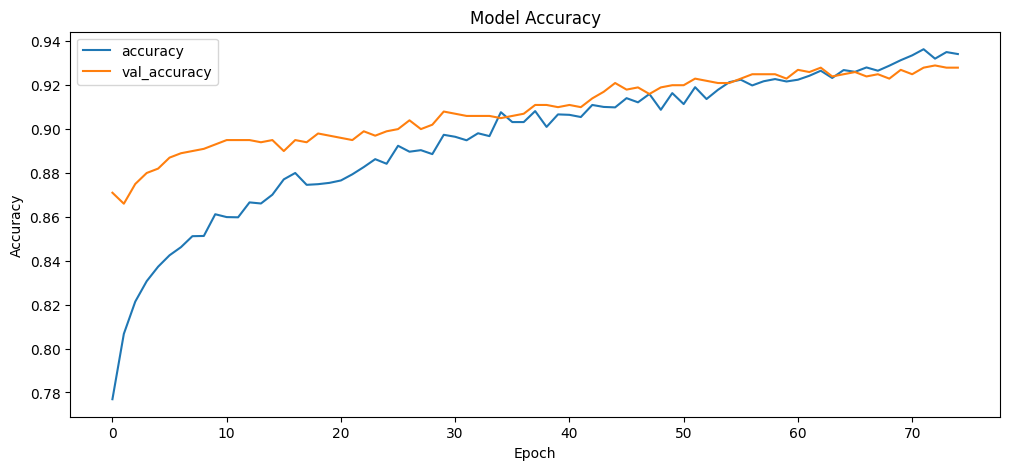

In [7]:
# The history.history["loss"] entry is a dictionary with as many values as epochs that the
# model was trained on.
df_loss_acc = pd.DataFrame(history_phase2.history)
df_loss= df_loss_acc[['loss','val_loss']]
df_loss.rename(columns={'loss':'train','val_loss':'validation'})
df_acc= df_loss_acc[['accuracy','val_accuracy']]
df_acc.rename(columns={'accuracy':'train','val_accuracy':'validation'})
df_loss.plot(title='Model loss',figsize=(12,5)).set(xlabel='Epoch',ylabel='Loss')
df_acc.plot(title='Model Accuracy',figsize=(12,5)).set(xlabel='Epoch',ylabel='Accuracy')

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 454ms/step


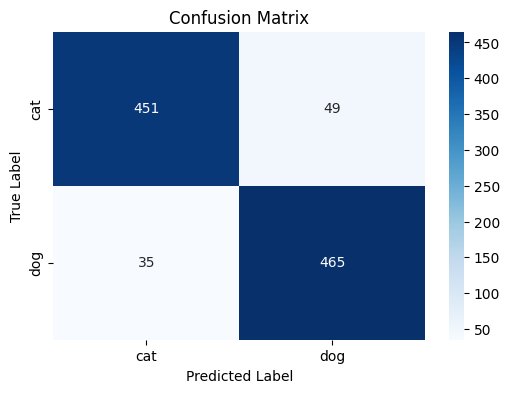

In [8]:
y_pred = model.predict(test_gen)
y_pred_classes = (y_pred > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Define the class names for the binary classification
binary_class_names = [class_names[class_1_label], class_names[class_2_label]]

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Number of misclassified images: 84


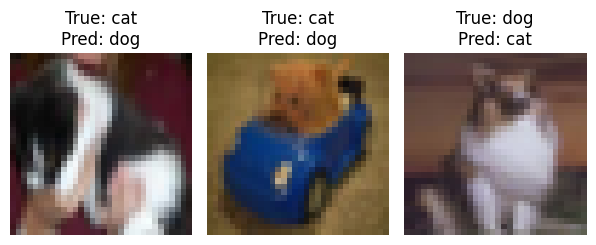

In [9]:

# Find the indices where the true labels do not match the predicted labels
misclassified_indices = np.where(y_pred_classes != y_test)[0]

# Print the number of misclassified images
print(f"Number of misclassified images: {len(misclassified_indices)}")

# Filter for high-confidence errors: probability <0.1 or >0.9
misclassified_indices = [i for i in misclassified_indices if y_pred[i] < 0.05 or y_pred[i] > 0.95]


# Plot a few of the misclassified images
plt.figure(figsize=(10, 10))


num_images_to_plot = min(20, len(misclassified_indices)) # Plot up to 20 misclassified images

for i in range(num_images_to_plot):
    index = misclassified_indices[i]
    plt.subplot(4, 5, i + 1) # Adjust subplot grid based on the number of images
    # Display the original image from the test set
    plt.imshow(x_test[index])
    # Display the true and predicted labels
    true_label = class_names[class_1_label] if y_test[index] == 0 else class_names[class_2_label]
    predicted_label = class_names[class_1_label] if y_pred_classes[index] == 0 else class_names[class_2_label]
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we implemented and compared several neural network models (MLP and CNN variations) for binary image classification on a subset of the CIFAR-10 dataset (distinguishing between 'cat' and 'dog' images).

The models trained were:
- MLP Model
- Basic CNN Model
- CNN with Batch Normalization and Dropout (LeNet-5 style)
- CNN with Data Augmentation (LeNet-5 style)
- Larger CNN with Data Augmentation
- Transfer Learning with EfficientNetB0

Here's a summary of the performance on the test set for each model:

| Model                                     | Train Accuracy | Test Accuracy |
|-------------------------------------------|----------------|---------------|
| MLP Model              | 98%          | 61%         |
| Basic CNN Model                           | 93%          | 73%         |
| CNN with BN and Dropout (LeNet-5 style)   | 80%          | 75%         |
| CNN with Data Augmentation (LeNet-5 style)| 80%          | 76%         |
| Larger CNN with Data Augmentation         | 99%(sign of overfitiing)          | 83%         |
| Transfer Learning with EfficientNetB0     | 92%           | 91%         |


Based on the evaluation on the test set, the **Transfer Learning with EfficientNetB0** model achieved the highest accuracy of **91**% in distinguishing between 'cat' and 'dog' images.

The confusion matrices and loss/accuracy plots for each model provide further insights into their performance and convergence during training. The analysis of misclassified images from the best performing model highlighted instances where the model struggled, often due to ambiguous or challenging visual features.

Overall, the experiments demonstrated the effectiveness of CNNs, batch normalization, data augmentation, and especially transfer learning in improving the performance of image classification models on this dataset.